# Using Multi-layer Preceptron for binary prediction between pre-term and term neonatal brain using MRI features in pkl form.

Key steps:
1) Data processing + splitting data into training and testing set
2) Neural Network pipeline setup
3) Training and Validation pipeline setup
4) Plotting Validation loss and Accuracy.



Importing all the necessary modules

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


Importing the file that we need

In [15]:
filepath = "./prem_vs_termwrois.pkl"
df = pd.read_pickle(filepath)
data = df.values[:,:-2]
y = df.values[:,-1]
print(data)
print(y)
print(df.columns)


[[ 1.1286763   1.00634468  1.1051054  ... -0.01697977 -0.05081671
   0.09802839]
 [ 1.13097095  1.08568406  1.05116749 ... -0.0491032  -0.05045224
   0.08470406]
 [ 1.27108824  1.13569081  1.17024696 ... -0.0308224  -0.0220999
   0.08480169]
 ...
 [ 1.1360445   1.02222812  1.18946874 ... -0.01774352 -0.01896123
   0.10068046]
 [ 1.21338713  1.02229774  1.15946352 ... -0.03937253 -0.03735522
   0.06477939]
 [ 1.27724886  1.03226352  1.227723   ... -0.05727959 -0.05484535
   0.08332317]]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.]
Index(['DA_0_roi_100_right', 'DA_0_roi_10_right', 'DA_0_roi_11_right',
       'DA_0_roi_12_right', 'DA_0_roi_13_right', 'DA_0_roi_14_right',
       'DA_0_roi_15_right', 'DA_0_roi_16_right', 'DA_0_roi_

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(data,y,test_size = 0.2, random_state = 42)

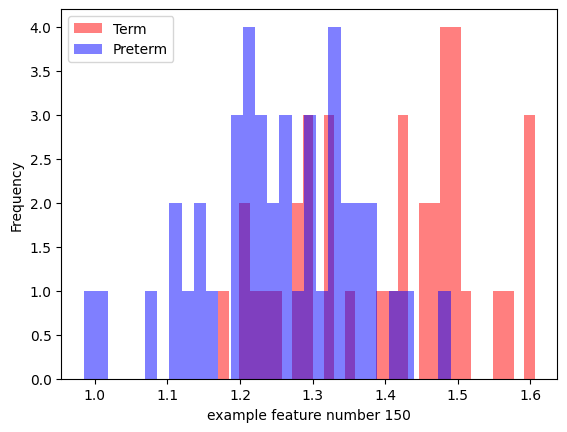

In [18]:
y_train = y_train.flatten()
y_test = y_test.flatten()
example_feature = 150
plt.hist(np.array(X_train[y_train==0,example_feature]).flatten(), bins = 30,alpha = 0.5,color = 'red')
plt.hist(np.array(X_train[y_train==1,example_feature]).flatten(), bins=30,alpha = 0.5,color = 'blue')
plt.xlabel('example feature number {}'.format(example_feature))
plt.ylabel('Frequency')
plt.legend(['Term','Preterm']);

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
from sklearn.feature_selection import SelectKBest ,f_classif, VarianceThreshold
filter = VarianceThreshold(threshold = 0)
X_train_filtered = filter.fit_transform(X_train)
X_test_filtered = filter.transform(X_test)
selectKbest = SelectKBest(score_func=f_classif, k=40)
X_train_selected = selectKbest.fit_transform(X_train_filtered,y_train)
X_test_selected = selectKbest.transform(X_test_filtered)

In [23]:
print(X_train.shape)
print(X_test.shape)

(80, 300)
(21, 300)


In [24]:
print(X_train_selected)

[[ 0.24339762  0.1947817   0.60251893 ...  0.26641946  0.56119915
  -1.01292006]
 [ 1.06541107  2.01710876  1.61948558 ...  1.13771945  2.27924859
   2.63526517]
 [-0.29462811 -0.16339286 -0.16407483 ... -0.31736415 -0.0803364
   0.74854194]
 ...
 [ 1.47954291  0.83000231  2.26119118 ...  2.70243219  1.70706499
  -0.84312124]
 [-0.03390647  0.91508416 -0.45159665 ... -0.51939394  0.57822632
  -1.04796043]
 [-0.37928904 -0.69412848 -1.24284622 ... -0.36752962 -1.05997478
   0.5104281 ]]


Defining a class MLP which takes 300 of our features as input. it has  3 hidden layers which is then passed to a sigmoid function, between the layers is a relu activation function.

In [49]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP,self).__init__()
        self.fc1 = nn.Linear(40,30)
        self.fc2 = nn.Linear(30,30)
        self.fc3 = nn.Linear(30,30)
        self.fc4 = nn.Linear(30,10)
        self.fc5 = nn.Linear(10,1)
        self.dropout = nn.Dropout(p = 0.5)

    def forward(self,x):
        x = x.float()
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        x = F.relu(self.fc4(x))
        x = self.dropout(x)
        x = self.fc5(x)
        return x


model = MLP()

Defining the optimiser (SGD) and the loss function (BCELoss)

In [50]:

optimizer = torch.optim.Adam(model.parameters(),lr = 0.005, weight_decay = 0.0001)
loss_function = torch.nn.BCEWithLogitsLoss()

packaging the train and test data into tensordatasets and using Dataloader to batch and shuffle the dataset

In [51]:
dataset_tensor_train = torch.utils.data.TensorDataset(torch.tensor(X_train_selected,dtype=torch.float32),torch.tensor(y_train,dtype=torch.float32).reshape(-1,1))
dataset_tensor_test = torch.utils.data.TensorDataset(torch.tensor(X_test_selected,dtype=torch.float32),torch.tensor(y_test,dtype=torch.float32).reshape(-1,1))
train_dataloader = torch.utils.data.DataLoader(dataset_tensor_train, batch_size = 64, shuffle = True)
test_dataloader = torch.utils.data.DataLoader(dataset_tensor_test, batch_size = 64, shuffle = False)

Training function

In [52]:
def train(epoch,log_interval = 2):
    model.train()
    for i, (input_number,labels) in enumerate(train_dataloader):
        optimizer.zero_grad()
        output = model(input_number)
        loss = loss_function(output,labels)
        loss.backward()
        optimizer.step()
        if i % log_interval == 0:
            print("Train Epoch: {} Loss: {}  ".format(epoch,loss.item()))


Validation Function

In [53]:
def validation(loss_number, accuracy_number):
    model.eval()
    correct = 0
    validation_loss = 0
    with torch.no_grad():
        for input_number, labels in test_dataloader:
            output = model(input_number)
            loss = loss_function(output,labels)
            validation_loss += loss.item() * input_number.size(0)
            pred = (output>0.5).float()
            correct += pred.eq(labels.data).sum().item()

    validation_loss = validation_loss / len(test_dataloader.dataset)
    loss_number.append(validation_loss)
    accuracy = 100 * correct/ len(test_dataloader.dataset)
    accuracy_number.append(accuracy)
    print('\nValidation set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format( validation_loss, correct, len(test_dataloader.dataset), accuracy))


Training the model and validating it, printing the result

In [54]:
epoch = 30
loss_num = []
accuracy_num = []
for epoch in range(1,epoch+1):
    train(epoch,log_interval = 2)
    validation(loss_num, accuracy_num)


Train Epoch: 1 Loss: 0.6980087757110596  

Validation set: Average loss: 0.6852, Accuracy: 12/21 (57%)

Train Epoch: 2 Loss: 0.6990048289299011  

Validation set: Average loss: 0.6833, Accuracy: 12/21 (57%)

Train Epoch: 3 Loss: 0.7000846862792969  

Validation set: Average loss: 0.6802, Accuracy: 12/21 (57%)

Train Epoch: 4 Loss: 0.6876785159111023  

Validation set: Average loss: 0.6740, Accuracy: 12/21 (57%)

Train Epoch: 5 Loss: 0.6846919655799866  

Validation set: Average loss: 0.6653, Accuracy: 12/21 (57%)

Train Epoch: 6 Loss: 0.6835566759109497  

Validation set: Average loss: 0.6530, Accuracy: 12/21 (57%)

Train Epoch: 7 Loss: 0.6855183243751526  

Validation set: Average loss: 0.6362, Accuracy: 12/21 (57%)

Train Epoch: 8 Loss: 0.6405300498008728  

Validation set: Average loss: 0.6134, Accuracy: 12/21 (57%)

Train Epoch: 9 Loss: 0.6442330479621887  

Validation set: Average loss: 0.5849, Accuracy: 17/21 (81%)

Train Epoch: 10 Loss: 0.6428190469741821  

Validation set: Aver

Plotting the validation loss and accuracy with each epoch

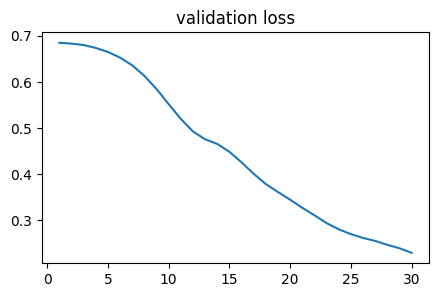

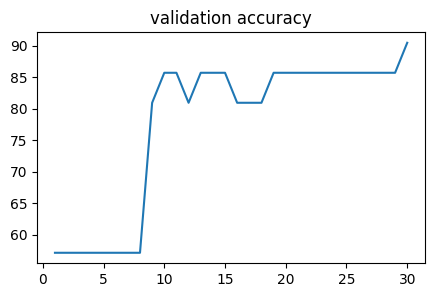

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))
plt.plot(np.arange(1,epoch+1), loss_num)
plt.title('validation loss')

plt.figure(figsize=(5,3))
plt.plot(np.arange(1,epoch+1), accuracy_num)
plt.title('validation accuracy');